In [77]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import activations
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from numpy import random

**Data Preparation**

In [78]:
N = 32 # number of rows and columns of the input square matrix
C = 10 # number of total classes (e.g. , 10 possible digits )
 # load the data and split it between train and test sets
( x_train , labels_train ) , ( x_test , labels_test ) = keras . datasets . cifar10 . load_data () # uint8 (0 -255)
print (" Input data type :", x_train . dtype )
print (" Min value :", x_train . min () )
print (" Max value :", x_train . max () )
print (" Shape of the training examples :", x_train . shape )
print (" Shape of the test examples :", x_test . shape )
# scale images to the [0 , 1] range
x_train = x_train / 255
x_test = x_test / 255
print (" Input data type ( after scaling ):", x_train . dtype )
print (" Min value ( after scaling ):", x_train . min () )
print (" Max value ( after scaling ):", x_train . max () )

 # make sure images have shape (28 , 28 , 1)
n_examples_train = x_train . shape [0]
n_examples_test = x_test . shape [0]
x_train = x_train . reshape (( n_examples_train , N , N , 3) )
x_test = x_test . reshape (( n_examples_test , N , N , 3) )

print (" Shape of the training examples ( after reshaping ):", x_train . shape )
print (" Shape of the test examples ( after reshaping ):", x_test . shape )

 # convert labels to one - hot encoded labels using a custom method (to be defined in the exercises 11 and 12)
print (" Shape of the trainin labels :", labels_train . shape )
print (" Shape of the test labels :", labels_test . shape )
y_train =  keras.utils.to_categorical ( labels_train , C )
y_test =  keras.utils.to_categorical ( labels_test , C)
print (" Shape of the trainin labels ( after one - hot encoding ):", y_train . shape )
print (" Shape of the test labels ( after one - hot encoding ):", y_test . shape )


 Input data type : uint8
 Min value : 0
 Max value : 255
 Shape of the training examples : (50000, 32, 32, 3)
 Shape of the test examples : (10000, 32, 32, 3)
 Input data type ( after scaling ): float64
 Min value ( after scaling ): 0.0
 Max value ( after scaling ): 1.0
 Shape of the training examples ( after reshaping ): (50000, 32, 32, 3)
 Shape of the test examples ( after reshaping ): (10000, 32, 32, 3)
 Shape of the trainin labels : (50000, 1)
 Shape of the test labels : (10000, 1)
 Shape of the trainin labels ( after one - hot encoding ): (50000, 10)
 Shape of the test labels ( after one - hot encoding ): (10000, 10)


**Neural Network Design**

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,794 (870.29 KB)

 Trainable params: 222,794 (870.29 KB)

 Non-trainable params: 0 (0.00 B)

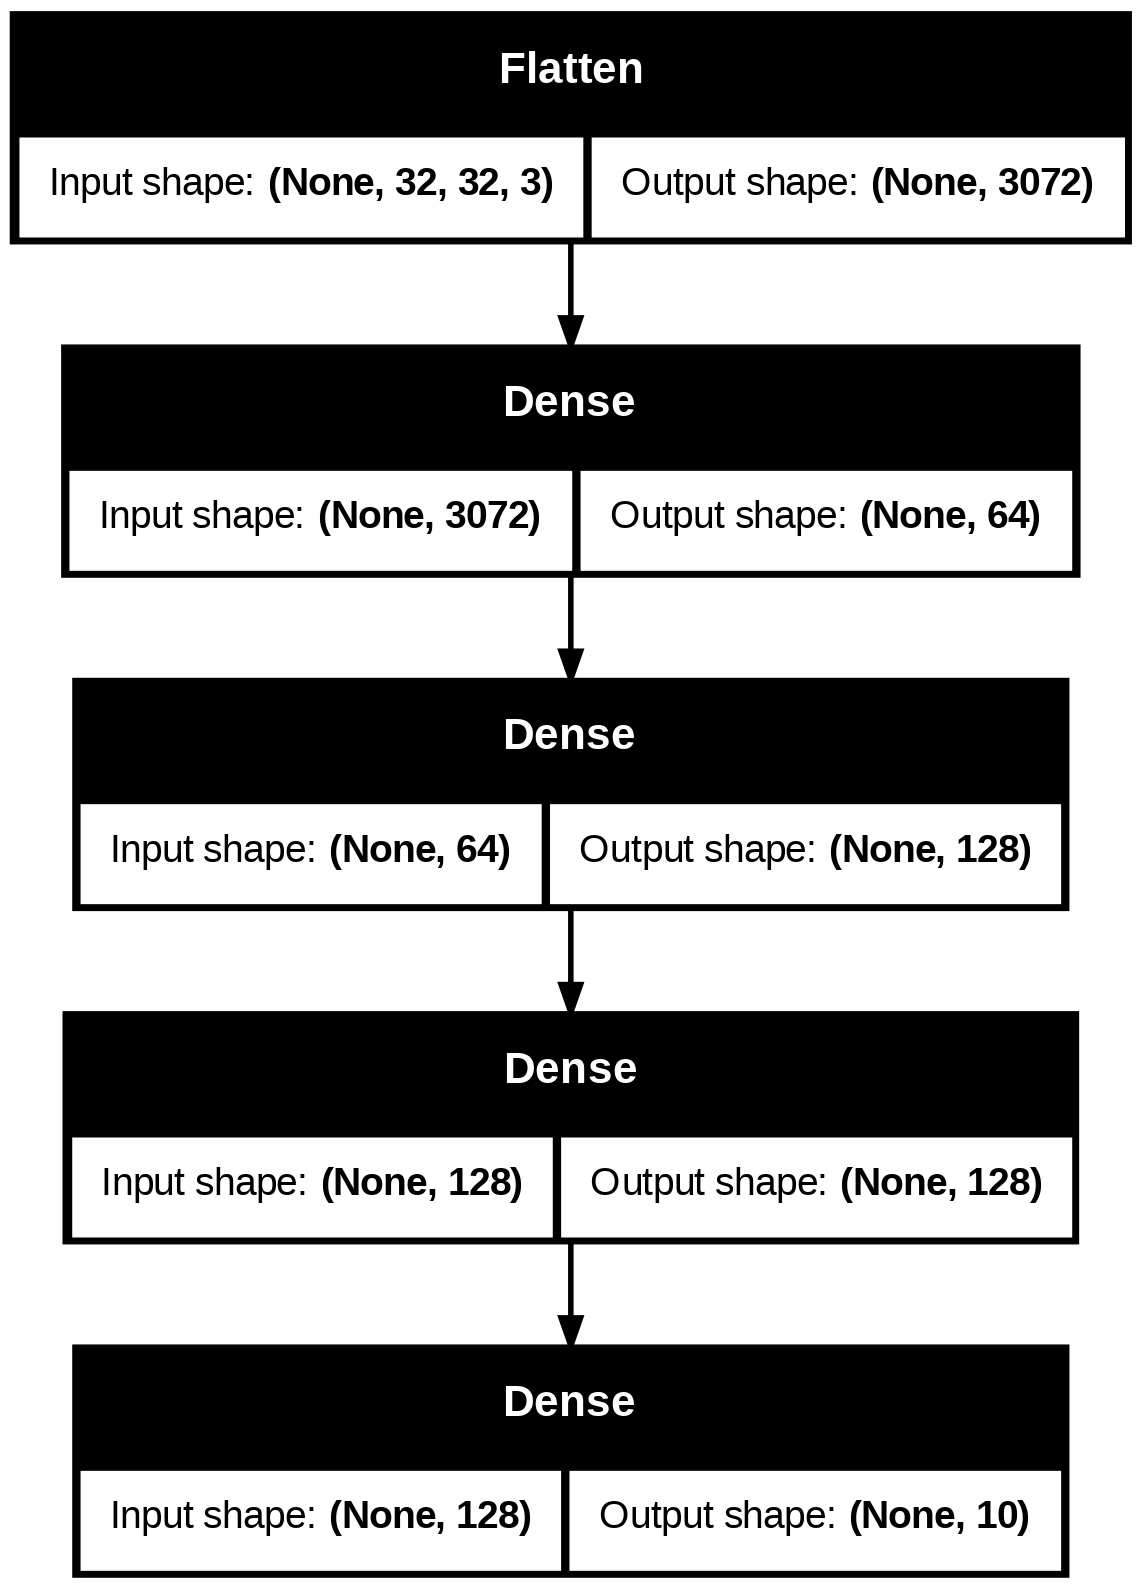

In [79]:
input_shape = (N , N , 3) # input dimension (grey - scale image 28 x 28 , represented as a single input feature map 28 x28x1 )

 # model design
model = keras.Sequential (
[
 keras.Input ( shape = input_shape ) , # input layer
 keras.layers.Flatten () , # flatten layer ( from multiple dimensions to a 1 -D)

 keras.layers.Dense (64 , activation = 'relu') , # 1-D layer of 64 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
#keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
#####keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
 #####keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (C , activation ='softmax') , # output layer with C neurons ,
#fully - connected with the preceding layer , activated via softmax
 ]
 )

 # inspect model
model.summary ()
keras.utils.plot_model(model, show_shapes=True)


**Neural Network Training and plot losses**

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,794 (870.29 KB)

 Trainable params: 222,794 (870.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1293 - loss: 2.2926 - val_accuracy: 0.2304 - val_loss: 2.1605
Epoch 2/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1904 - loss: 2.1693 - val_accuracy: 0.2698 - val_loss: 2.0286
Epoch 3/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2264 - loss: 2.0728 - val_accuracy: 0.2810 - val_loss: 1.9765
Epoch 4/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2384 - loss: 2.0286 - val_accuracy: 0.3076 - val_loss: 1.9217
Epoch 5/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2518 - loss: 1.9894 - val_accuracy: 0.3148 - val_loss: 1.8804
Epoch 6/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2670 - loss: 1.9582 - val_accuracy: 0.3398 - val_loss: 1.8541
Epoch 7/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2822 - loss: 1.9365 - val_accuracy: 0.3442 - val_loss: 1.8346
Epoch 8/300
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2937 - loss: 1.9160 - 

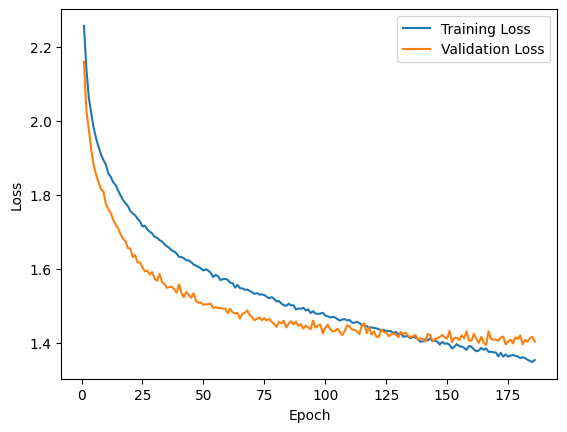

In [81]:
input_shape = (N , N , 3) # input dimension (grey - scale image 28 x 28 , represented as a single input feature map 28 x28x1 )

 # model design
model = keras.Sequential (
[
 keras.Input ( shape = input_shape ) , # input layer
 keras.layers.Flatten () , # flatten layer ( from multiple dimensions to a 1 -D)

 keras.layers.Dense (64 , activation = 'relu') , # 1-D layer of 64 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (128 , activation ='relu') , # 1 -D layer of 128 neurons , fully -
#connected with the preceding layer , activated via rectified linear function ( ReLUs )
 keras.layers.Dropout (0.25) , # application of dropout to the output of the
#preceding layer with a dropout probability of 0.25 (25% neurons dropped out during
#training )

 keras.layers.Dense (C , activation ='softmax') , # output layer with C neurons ,
#fully - connected with the preceding layer , activated via softmax
 ]
 )

 # inspect model
model.summary ()
keras.utils.plot_model(model, show_shapes=True)






lr = 0.001 # learning rate
momentum = 0.9 # momentum term
# defining the optimizer ( stochastic gradient descent with momentum )
optimizer = keras.optimizers.SGD ( learning_rate = lr , momentum = momentum ) # SGD with
#momentum

# compiling the model = defining the desired loss function to be minimized , the
#algorithm to use for the optimization process, and other metrics to track
model.compile ( loss ='categorical_crossentropy', optimizer = optimizer , metrics =["accuracy"])

valid_ratio = 0.1 # ratio of the overall training set to held back as validation set
 # extracting the validation set as the first 10% of examples
x_valid = x_train [: round ( valid_ratio * n_examples_train ) ,: ,: ,:]
y_valid = y_train [: round ( valid_ratio * n_examples_train ) ,:]
labels_valid = labels_train [: round ( valid_ratio * n_examples_train )]
 # assigning back the training set as the remaining 90% of examples
x_train = x_train [ round ( valid_ratio * n_examples_train ) : ,: ,: ,:]
y_train = y_train [ round ( valid_ratio * n_examples_train ) : ,:]
labels_train = labels_train [ round ( valid_ratio * n_examples_train ) :]


 # defining the ModelCheckpoint callback
model_checkpoint_callback = keras.callbacks.ModelCheckpoint (
filepath ='best_mdl.keras', # set to ’best_mdl . keras ’ if you want only the best
#model , overall or to ’{ epoch :02 d} -{ val_loss :.5 f}. keras ’ if you want to save the
#best model as the training proceed ( best model over time )
monitor ='val_loss', # set to the metric that you want to track for the early
#stopped model ( evaluated offline )
 save_best_only = True )


early_stopping_callback = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 20, verbose = 1)

model_callbacks = [
    model_checkpoint_callback ,
    early_stopping_callback ,
]

 # start optimizing the network
batch_size = 128 # mini - batch size
max_epochs = 300# maximum number of epochs
history = model.fit ( x_train , y_train ,
batch_size = batch_size ,
epochs = max_epochs ,
validation_data =( x_valid , y_valid ) ,
callbacks =[model_callbacks ])


 # extracting training and validation losses , training and validation accuracies
train_loss = history.history ['loss']
train_acc = history.history ['accuracy']
valid_loss = history.history ['val_loss']
valid_acc = history.history ['val_accuracy']


xaxis = np.linspace(1, len(history.history['loss']), len(history.history['loss']))
plt.figure()
plt.plot(xaxis, history.history['loss'], label='Training Loss')
plt.plot(xaxis, history.history['val_loss'], label='Validation Loss')
plt.legend(loc='best')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

(300,)
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180. 181. 182.
 183. 184. 185. 186. 187. 188. 189. 190. 191. 192. 193. 194. 195. 196.

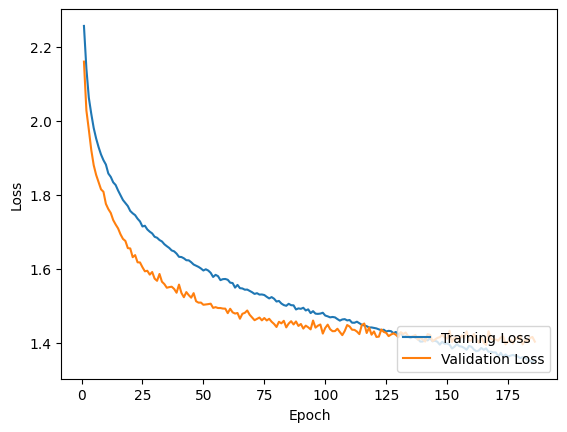

In [82]:
xaxis = np.linspace(1,max_epochs,max_epochs)
print(xaxis.shape)
print(xaxis)
print(len(history.history['loss']))

xaxis = np.linspace(1, len(history.history['loss']), len(history.history['loss']))
plt.figure()
plt.plot(xaxis, history.history['loss'], label='Training Loss')
plt.plot(xaxis, history.history['val_loss'], label='Validation Loss')
plt.legend(loc='lower right')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

**Trained Network evaluation and accuracy computation**

In [83]:
model = keras.models.load_model ('best_mdl.keras')
proba_test = model.predict ( x_test )
proba_valid = model.predict( x_valid )
proba_train = model.predict( x_train )

print(proba_test)
print(proba_test.shape)
which_number_is_it = np.argmax(proba_test, axis=1)
print(which_number_is_it.shape)
print(which_number_is_it);
print('Length of labels_test:',labels_test.shape)
print(type(labels_test))
print(type(which_number_is_it))
#plt.figure()
#plt.plot(labels_test,which_number_is_it,'p')

y_pred_valid = np.argmax(proba_valid, axis=1)
y_pred_train = np.argmax(proba_train, axis=1)

print(labels_test)
print(type(labels_test))
print((which_number_is_it == labels_test).shape)
#print(np.sum(which_number_is_it == labels_test)/len()
labels_test = labels_test.flatten()
labels_valid = labels_valid.flatten()
labels_train = labels_train.flatten()


accuracy_test = np.sum(which_number_is_it == labels_test)*100/len(labels_test)
accuracy_valid = np.sum(y_pred_valid == labels_valid)*100/len(labels_valid)
accuracy_train = np.sum(y_pred_train == labels_train)*100/len(labels_train)
print('Accuracy on test set: ',accuracy_test)
print('Accuracy on validation set: ',accuracy_valid)
print('Accuracy on train set: ',accuracy_train)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
[[0.11208507 0.03362308 0.03464236 ... 0.00936128 0.38660848 0.00978106]
 [0.03036176 0.27160263 0.00131856 ... 0.0010849  0.20292506 0.48873514]
 [0.12318093 0.12312828 0.00557221 ... 0.00321974 0.6286662  0.10409198]
 ...
 [0.00670765 0.00072302 0.11535773 ... 0.06137602 0.00190971 0.00314866]
 [0.06688493 0.02348772 0.10656473 ... 0.04503408 0.08320401 0.01498771]
 [0.02272466 0.00347484 0.10529668 ... 0.64743316 0.00186962 0.0058556 ]]
(10000, 10)
(10000,)
[8 9 8 ... 5 3 7]
Length of labels_test: (10000, 1)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]
<class 'numpy.ndarray'>
(10000, 10000)
Accuracy on test set:  49.84
Accuracy on validation set:  49.2
Accuracy on train set:  58.6125


**Confusion matrices plot**

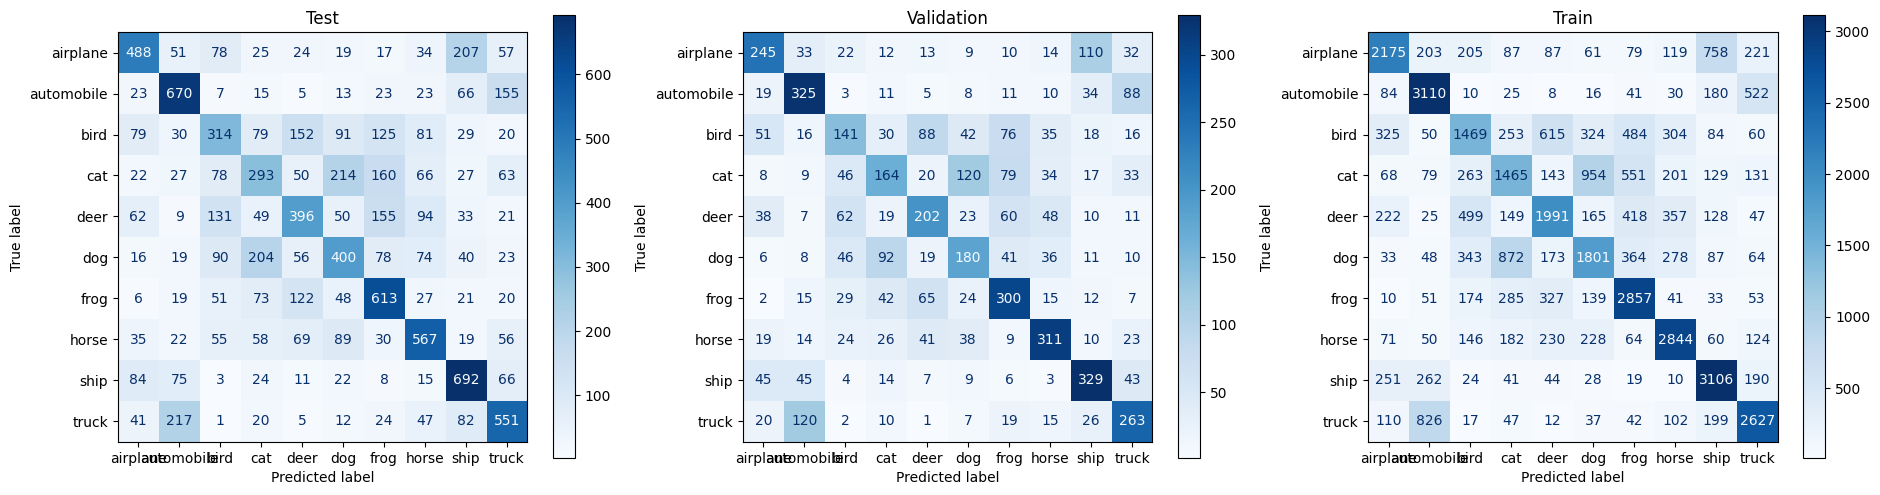

In [84]:
cm_test = confusion_matrix(labels_test, which_number_is_it)
cm_valid = confusion_matrix(labels_valid, y_pred_valid)
cm_train = confusion_matrix(labels_train, y_pred_train)
#print(cm_test)
lab = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=lab)
disp.plot(cmap='Blues', values_format='d',ax = axes[0])  # 'd' = integer counts [web:3][web:7]
axes[0].set_title('Test')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_valid, display_labels=lab)
disp.plot(cmap='Blues', values_format='d',ax=axes[1])  # 'd' = integer counts [web:3][web:7]
axes[1].set_title('Validation')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=lab)
disp.plot(cmap='Blues', values_format='d',ax=axes[2])  # 'd' = integer counts [web:3][web:7]
axes[2].set_title('Train')

plt.tight_layout()
plt.show()



**Layer analysis**

In [85]:
model = keras.models.load_model('best_mdl.keras')
layers = model.layers # list containing all trained layers
layer = layers [1] # first fully - connected layer
weights , biases = layer.get_weights() # accessing weights and biases
print('Weights: ', weights)

Weights:  [[ 0.00985147  0.04152757 -0.04821068 ...  0.01493796  0.02999772
  -0.0073045 ]
 [ 0.01723655 -0.00302936 -0.05037772 ...  0.0197347   0.02823161
  -0.03598827]
 [ 0.08202256  0.08994608 -0.00063084 ... -0.00453853 -0.02770061
  -0.02691905]
 ...
 [ 0.01225548 -0.03664223  0.04557892 ... -0.04127833 -0.05387023
  -0.01919748]
 [ 0.01425252 -0.05297766  0.00180771 ... -0.01188045 -0.0852215
   0.01259851]
 [ 0.09220602 -0.01283762 -0.01297163 ... -0.0376537  -0.03370486
  -0.02912972]]


**Model testing on a random image**

(1, 32, 32, 3)


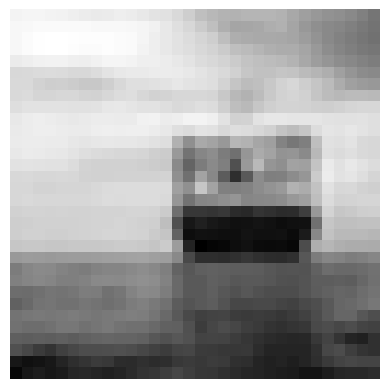

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[3.7189263e-01 2.9680277e-03 2.3415532e-02 1.7959651e-03 1.7582286e-02
  9.6497714e-04 1.9388090e-04 6.1329314e-04 5.7891178e-01 1.6616371e-03]]
ship
Indovinato


In [87]:
idx = random.randint(0, 10000-1)

trial = x_test[idx:idx+1, :, :, :]   # shape (1, 28, 28, 1)

# Option 2: start from (28, 28, 1) and add axis

img = x_test[idx, :, :, 0]      # (28, 28)
#trial = np.expand_dims(img, axis=0)  # shape (1, 28, 28, 1)

print(trial.shape)

plt.figure()
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()


y_prob_trial = model.predict(trial);
print(y_prob_trial)
y_pred_trial = np.argmax(y_prob_trial)
print(lab[y_pred_trial])
if y_pred_trial == labels_test[idx]:
  print("Indovinato")
else:
  print("The photo is not representing a", lab[y_pred_trial], ", IT IS A", lab[labels_test[idx]])


In [ ]:
plt.imshow(img, cmap=None)